EJERCICIO GRUPO 2

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from random import randrange
import datetime
from scipy.stats import norm

# Cargar el dataset
df = pd.read_csv('cybersecurity_intrusion_data.csv')

# Mostrar el total de eventos registrados
total_eventos = len(df)
print(f"Total de eventos registrados: {total_eventos}")

# Calcular el porcentaje de uso de los puertos
# Primero, verifiquemos los tipos de protocolo (puerto).
porcentaje_protocolos = df['protocol_type'].value_counts(normalize=True) * 100
print("\nPorcentaje de uso de los puertos:")
print(porcentaje_protocolos)

# Calcular el porcentaje de navegadores usados
porcentaje_navegadores = df['browser_type'].value_counts(normalize=True) * 100
print("\nPorcentaje de navegadores usados:")
print(porcentaje_navegadores)

Total de eventos registrados: 9537

Porcentaje de uso de los puertos:
protocol_type
TCP     69.455804
UDP     25.228059
ICMP     5.316137
Name: proportion, dtype: float64

Porcentaje de navegadores usados:
browser_type
Chrome     53.863899
Firefox    20.383768
Edge       15.403167
Unknown     5.263710
Safari      5.085457
Name: proportion, dtype: float64


In [2]:
print(df)

     session_id  network_packet_size protocol_type  login_attempts  \
0     SID_00001                  599           TCP               4   
1     SID_00002                  472           TCP               3   
2     SID_00003                  629           TCP               3   
3     SID_00004                  804           UDP               4   
4     SID_00005                  453           TCP               5   
...         ...                  ...           ...             ...   
9532  SID_09533                  194          ICMP               3   
9533  SID_09534                  380           TCP               3   
9534  SID_09535                  664           TCP               5   
9535  SID_09536                  406           TCP               4   
9536  SID_09537                  340           TCP               6   

      session_duration encryption_used  ip_reputation_score  failed_logins  \
0           492.983263             DES             0.606818              1   
1  

In [11]:
# Función para generar fechas aleatorias entre 2022 y 2025
def generar_fecha_aleatoria():
    # Generar año entre 2022 y 2025
    año = randrange(2022, 2026)
    # Generar mes entre 1 y 12
    mes = randrange(1, 13)
    # Generar día entre 1 y 28 (para evitar problemas con días de mes)
    dia = randrange(1, 29)
    return datetime.date(año, mes, dia)

# Función para generar horas aleatorias (en formato HH:MM:SS)
def generar_hora_aleatoria():
    # Generar hora, minuto y segundo aleatorios
    hora = randrange(0, 24)
    minuto = randrange(0, 60)
    segundo = randrange(0, 60)
    return f"{hora:02}:{minuto:02}:{segundo:02}"

# Crear las nuevas columnas con fechas y horas aleatorias
df['fecha'] = [generar_fecha_aleatoria() for _ in range(len(df))]
df['hora'] = [generar_hora_aleatoria() for _ in range(len(df))]

# Mostrar las primeras filas del dataframe con las nuevas columnas
print(df.head())

  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected       fecha      hora  
0         Edge                    0                1  2024-05-22  21:

In [7]:
print(df.head())

  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected       fecha      hora  
0         Edge                    0                1  2025-10-06  11:

In [6]:
print(df)

     session_id  network_packet_size protocol_type  login_attempts  \
0     SID_00001                  599           TCP               4   
1     SID_00002                  472           TCP               3   
2     SID_00003                  629           TCP               3   
3     SID_00004                  804           UDP               4   
4     SID_00005                  453           TCP               5   
...         ...                  ...           ...             ...   
9532  SID_09533                  194          ICMP               3   
9533  SID_09534                  380           TCP               3   
9534  SID_09535                  664           TCP               5   
9535  SID_09536                  406           TCP               4   
9536  SID_09537                  340           TCP               6   

      session_duration encryption_used  ip_reputation_score  failed_logins  \
0           492.983263             DES             0.606818              1   
1  

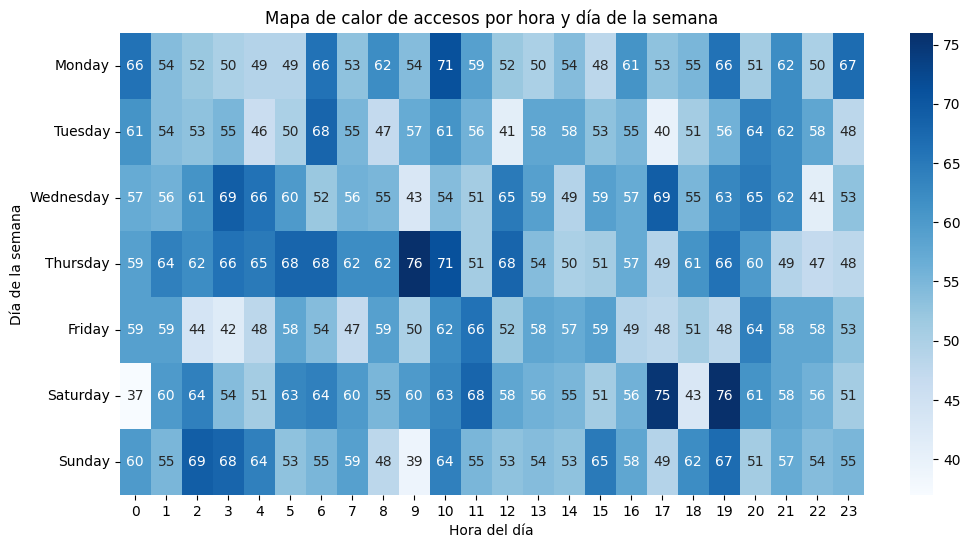

In [12]:
# Convertir la columna 'fecha' a tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Extraer día de la semana y hora
df['dia_semana'] = df['fecha'].dt.day_name()  # Lunes, Martes, etc.
df['hora'] = pd.to_datetime(df['hora'], format="%H:%M:%S").dt.hour  # Solo extraer la hora

# Crear una tabla pivote con la cantidad de accesos por día y hora
heatmap_data = df.pivot_table(index="dia_semana", columns="hora", aggfunc="size", fill_value=0)

# Reordenar los días de la semana en orden lógico
dias_ordenados = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data.reindex(dias_ordenados)

# Crear el mapa de calor
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="Blues", annot=True, fmt="d")

# Configurar etiquetas y título
plt.title("Mapa de calor de accesos por hora y día de la semana")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")

# Mostrar el gráfico
plt.show()

Media del tiempo de sesión: 792.75 segundos
Desviación estándar: 786.56 segundos


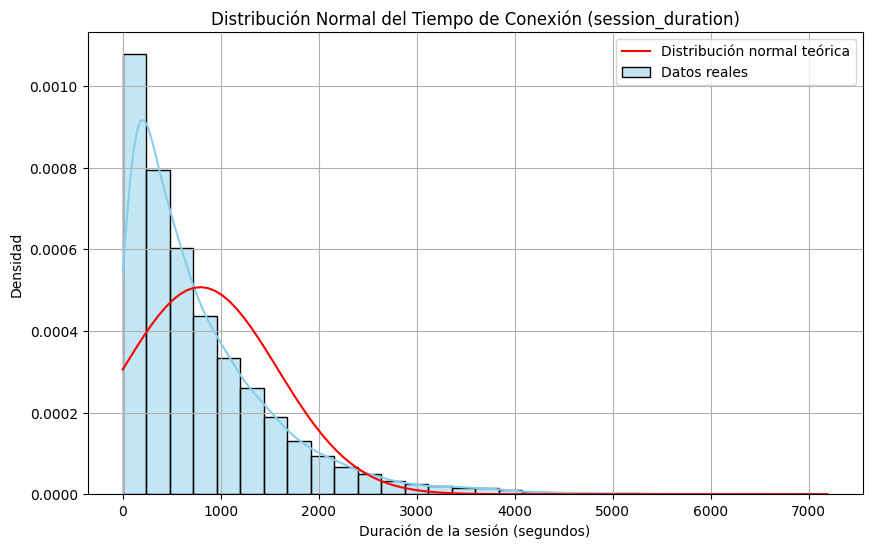

In [13]:
df['session_duration'] = pd.to_numeric(df['session_duration'], errors='coerce')
df = df.dropna(subset=['session_duration'])  # Eliminar posibles valores nulos

# Calcular media y desviación estándar
media = df['session_duration'].mean()
desviacion = df['session_duration'].std()

print(f"Media del tiempo de sesión: {media:.2f} segundos")
print(f"Desviación estándar: {desviacion:.2f} segundos")

# Crear histograma con curva de distribución normal
plt.figure(figsize=(10, 6))
sns.histplot(df['session_duration'], kde=True, bins=30, stat="density", color="skyblue", label="Datos reales")

# Crear una curva de distribución normal teórica
x = np.linspace(df['session_duration'].min(), df['session_duration'].max(), 100)
y = norm.pdf(x, media, desviacion)
plt.plot(x, y, 'r', label="Distribución normal teórica")

# Configuración del gráfico
plt.title("Distribución Normal del Tiempo de Conexión (session_duration)")
plt.xlabel("Duración de la sesión (segundos)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

In [14]:
df['ip_segura'] = df['ip_reputation_score'] > 0.5

# Crear tabla de resumen
resumen_ips = df.groupby('ip_segura').agg(
    intentos_fallidos=('failed_logins', 'sum'),
    total_sesiones=('session_id', 'count')
).reset_index()

# Renombrar valores para claridad
resumen_ips['ip_segura'] = resumen_ips['ip_segura'].map({True: "Segura (>0.5)", False: "No Segura (≤0.5)"})

# Mostrar tabla
print(resumen_ips)

          ip_segura  intentos_fallidos  total_sesiones
0  No Segura (≤0.5)              11729            7763
1     Segura (>0.5)               2746            1774


0    7763
1    1774
Name: total_sesiones, dtype: int64


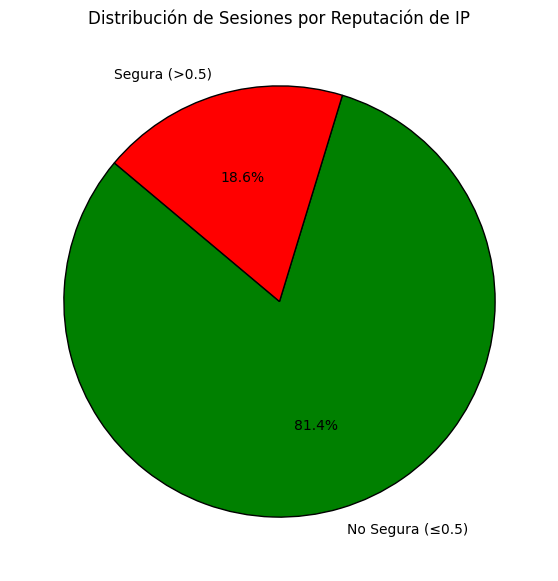

In [ ]:
labels = resumen_ips['ip_segura']
sizes = resumen_ips['total_sesiones']
colors = ["green", "red"]  # Verde para seguras, rojo para no seguras

# Crear el gráfico de pastel
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, wedgeprops={'edgecolor': 'black'})

# Configuración del gráfico
plt.title("Distribución de Sesiones por Reputación de IP")
plt.show()

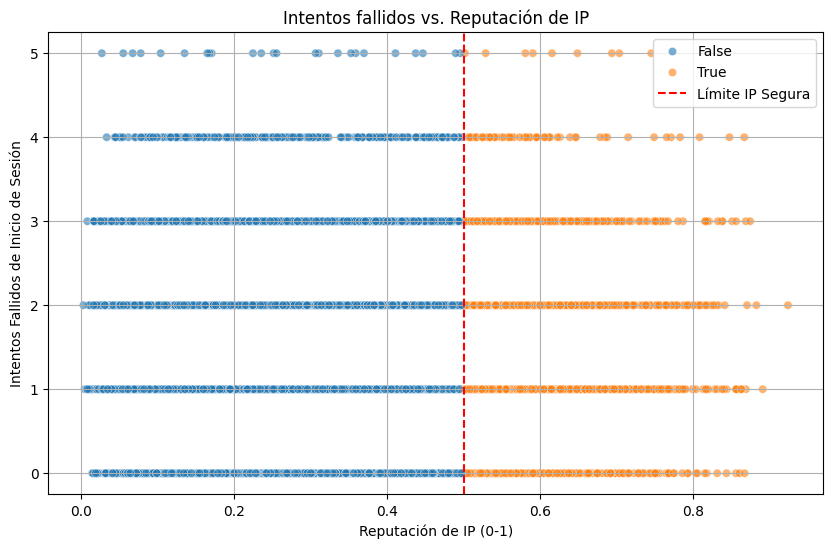

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="ip_reputation_score", y="failed_logins", alpha=0.6, hue="ip_segura")

# Configurar etiquetas y título
plt.title("Intentos fallidos vs. Reputación de IP")
plt.xlabel("Reputación de IP (0-1)")
plt.ylabel("Intentos Fallidos de Inicio de Sesión")
plt.axvline(0.5, color="red", linestyle="--", label="Límite IP Segura")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

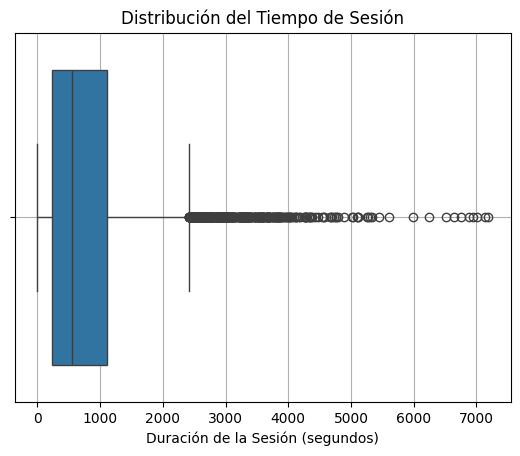

In [17]:
sns.boxplot(x=df["session_duration"])
plt.title("Distribución del Tiempo de Sesión")
plt.xlabel("Duración de la Sesión (segundos)")
plt.grid(True)
plt.show()

/tmp/ipykernel_15602/2812898504.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=browser_counts.index, y=browser_counts.values, palette="coolwarm")


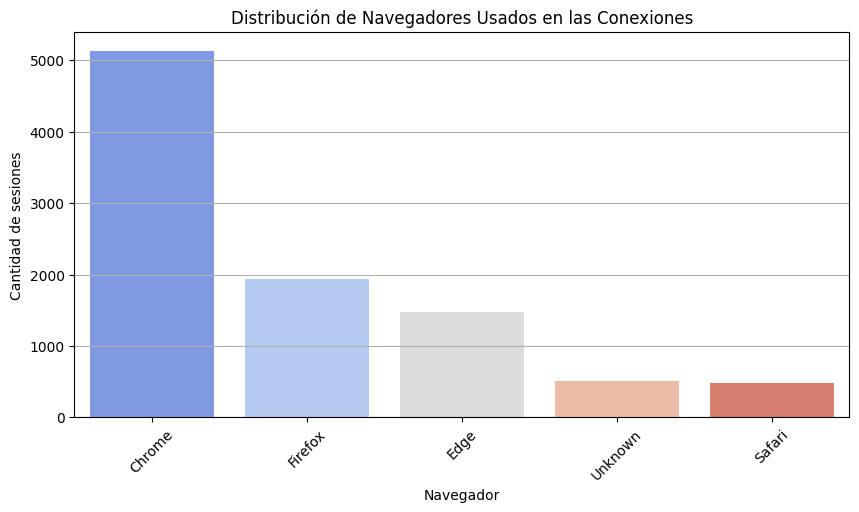

In [18]:
# Contar la cantidad de sesiones por navegador
browser_counts = df["browser_type"].value_counts()

# Crear gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=browser_counts.index, y=browser_counts.values, palette="coolwarm")

# Configurar etiquetas
plt.title("Distribución de Navegadores Usados en las Conexiones")
plt.xlabel("Navegador")
plt.ylabel("Cantidad de sesiones")
plt.xticks(rotation=45)  # Rotar etiquetas si son muchas
plt.grid(axis='y')

# Mostrar el gráfico
plt.show()

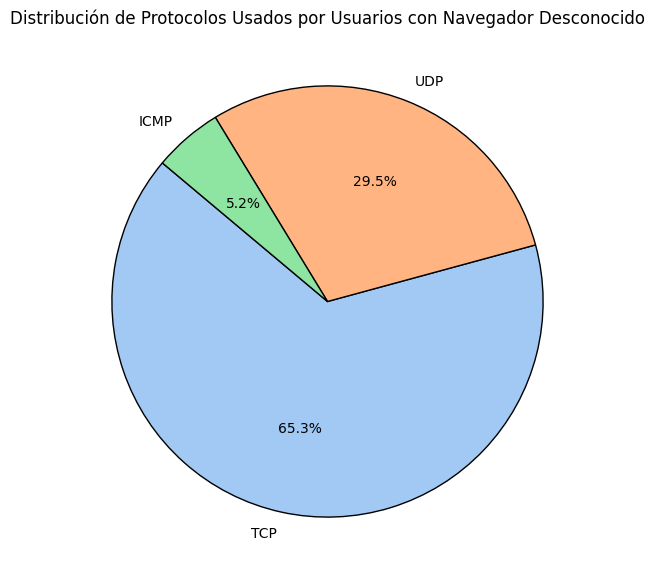

In [19]:
# Filtrar solo los usuarios con navegador "Unknown"
df_unknown = df[df["browser_type"] == "Unknown"]

# Contar la cantidad de sesiones por protocolo
protocol_counts = df_unknown["protocol_type"].value_counts()

# Crear gráfico de pastel
plt.figure(figsize=(7, 7))
plt.pie(protocol_counts, labels=protocol_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette("pastel", len(protocol_counts)), startangle=140, wedgeprops={'edgecolor': 'black'})

# Configuración del gráfico
plt.title("Distribución de Protocolos Usados por Usuarios con Navegador Desconocido")
plt.show()

Si la mayoría usa UDP, podría ser un intento de ataque DDoS.
Si hay muchos accesos TCP sospechosos, puede indicar exploración de puertos o intentos de acceso no autorizados.
Si se usan protocolos no esperados, vale la pena investigar si es tráfico legítimo o malicioso.
